# Step 4 - Modeling

In [1]:
#General imports
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math

In [2]:
#Sci-kit learn imports
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score, silhouette_score
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA

In [3]:
#set plot formatting to seaborn's default
sns.set() 

In [4]:
%matplotlib inline

In [5]:
RNG = 42

# Loading the cleaned NBA dataset from Step 3 - Preprocessing

In [6]:
df = pd.read_csv('../Data/nba-3-preprocessing.csv')

# Import pickle files

In [7]:
import joblib

cluster_X = joblib.load('../Data/cluster_X.pkl')
data = joblib.load('../Data/nba_modeling_data.pkl')

# Unpack the variables
X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

print(X_train.shape)

(290, 18)


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 290 entries, 209 to 102
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pts_36            290 non-null    float64
 1   oreb_36           290 non-null    float64
 2   dreb_36           290 non-null    float64
 3   ast_36            290 non-null    float64
 4   stl_36            290 non-null    float64
 5   blk_36            290 non-null    float64
 6   tov_36            290 non-null    float64
 7   fga_36            290 non-null    float64
 8   fg3a_36           290 non-null    float64
 9   fta_36            290 non-null    float64
 10  pf_36             290 non-null    float64
 11  fg_pct            290 non-null    float64
 12  fg3_pct           290 non-null    float64
 13  ft_pct            290 non-null    float64
 14  mpg               290 non-null    float64
 15  gp                290 non-null    float64
 16  years_experience  290 non-null    float64
 17  

In [9]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 290 entries, 209 to 102
Series name: log_salary
Non-Null Count  Dtype  
--------------  -----  
290 non-null    float64
dtypes: float64(1)
memory usage: 4.5 KB


In [10]:
cluster_features = ["pts_36", "oreb_36", "dreb_36", "ast_36", "stl_36", "blk_36", "tov_36", "fga_36", "fg3a_36", "fta_36", "pf_36", "fg_pct", "fg3_pct", "ft_pct", 
                    "height_in", "weight_lb", "wingspan_in"]

model_features = ["pts_36", "oreb_36", "dreb_36", "ast_36", "stl_36", "blk_36", "tov_36", "fga_36", "fg3a_36", "fta_36", "pf_36", "fg_pct", "fg3_pct", "ft_pct", 
                  "mpg", "gp", "years_experience", "age"]

# Clustering

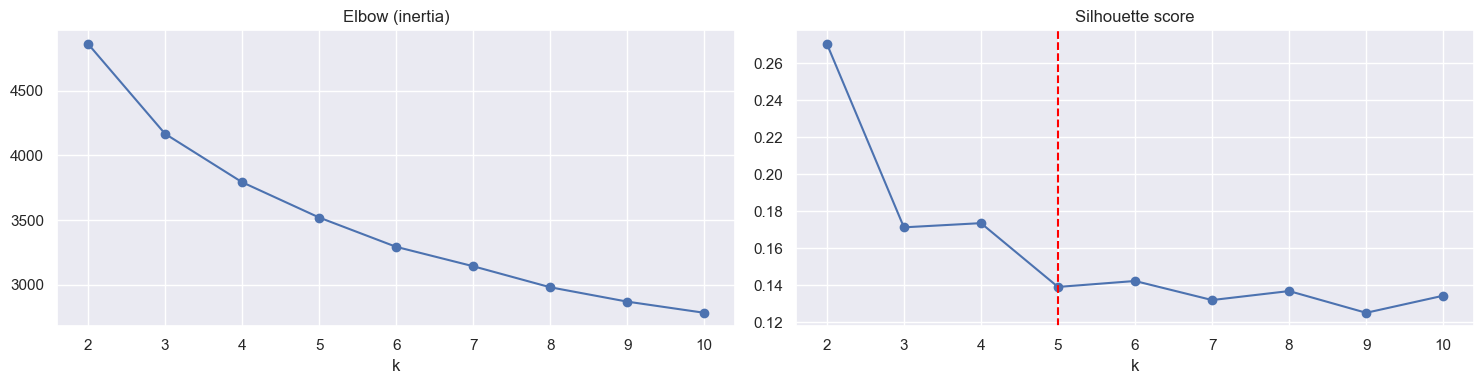

In [11]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn") #silence the Windows MKL warning

# Choose k based of inertia and silhoutte
inertia = []
sil = []

ks = range(2, 11)

for k in range(2, 11):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(cluster_X)
    inertia.append(km_k.inertia_)                       # elbow: within-cluster spread
    sil.append(silhouette_score(cluster_X, km_k.labels_))       # silhouette: cluster separation

# Scores flatten from k=4 onward so I choose k=5 based on the silhouette chart
K = 5
km = KMeans(n_clusters=K, n_init=10, random_state=RNG).fit(cluster_X)
df["cluster"] = km.labels_

fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(list(ks), inertia, "o-"); ax[0].set(title="Elbow (inertia)", xlabel="k")
ax[1].plot(list(ks), sil, "o-");     ax[1].set(title="Silhouette score", xlabel="k")
ax[1].axvline(K, color="red", ls="--")

plt.tight_layout(); plt.show()

# Visualize clusters in 2-D space

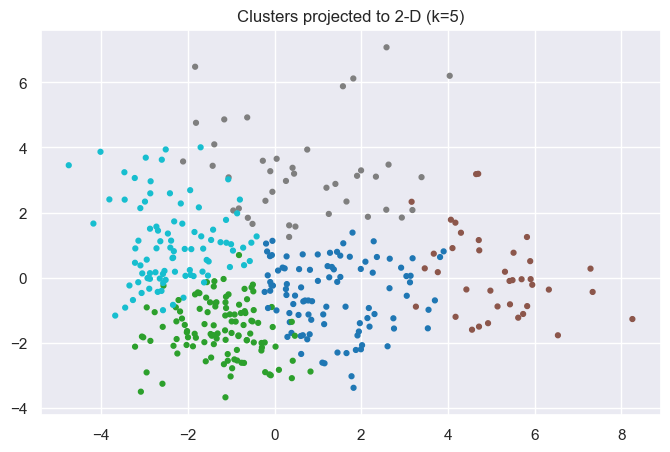

In [12]:
p2 = PCA(2, random_state=RNG).fit_transform(cluster_X)

fig, ax = plt.subplots(figsize=(8, 5)) 

ax.scatter(p2[:, 0], p2[:, 1], c=df["cluster"], cmap="tab10", s=12)
ax.set(title=f"Clusters projected to 2-D (k={K})")

plt.show()

In [13]:
# Profile the clusters
profile = df.groupby("cluster")[["height_in", "weight_lb", "pts_36", "oreb_36", "dreb_36", "ast_36","blk_36", "fga_36", "pf_36", "fg_pct", "salary"]].mean().round(2)
profile["n_players"] = df["cluster"].value_counts().sort_index()
profile

,height_in,weight_lb,pts_36,oreb_36,dreb_36,ast_36,blk_36,fga_36,pf_36,fg_pct,salary,n_players
cluster,,,,,,,,,,,,
0,80.39,225.34,14.87,2.15,5.58,2.75,0.93,11.60,3.33,0.48,7849383.60,97
1,76.96,203.04,13.54,1.12,3.47,3.31,0.43,11.16,2.81,0.43,7572676.08,112
2,82.66,246.68,14.28,4.54,7.34,2.64,1.68,9.57,3.94,0.61,11755882.28,38
3,81.29,232.24,24.85,1.81,6.60,4.75,0.99,17.84,2.64,0.50,36145265.72,41
4,75.88,199.16,20.16,0.89,3.86,5.88,0.40,16.03,2.77,0.45,17680683.71,91


In [14]:
# Sort by salary first, then grab the top 5 per cluster
top_players = (
    df.sort_values("salary", ascending=False)
    .groupby("cluster")
    .head(5)[["player", "cluster", "salary"]]
    .sort_values(["cluster", "salary"], ascending=[True, False])
    .reset_index(drop=True)
)

# Display the dataframe
top_players

,player,cluster,salary
0,OG Anunoby,0,39568966.0
1,Tobias Harris,0,26634146.0
2,John Collins,0,26580000.0
3,Draymond Green,0,25892857.0
4,Myles Turner,0,25318251.0
5,Andrew Wiggins,1,28223215.0
6,Devin Vassell,1,27000000.0
7,Mikal Bridges,1,24900000.0
8,Kentavious Caldwell-Pope,1,21621500.0
9,Cameron Johnson,1,21057065.0


In [15]:
# Based on stats and representative players: 
# Cluster 0: Versatile Forwards & Dynamic Bigs (3-and-D / Small-Ball Bigs)
# Cluster 1: Complementary Wings & Shooting Guards
# Cluster 2: Traditional Centers & Paint Anchors
# Cluster 3: Elite Superstar Frontcourt (Max-Contracts)
# Cluster 4: Elite Scoring Guards & Primary Playmakers

# Modeling

In [16]:
X_train.head()

,pts_36,oreb_36,dreb_36,ast_36,stl_36,blk_36,tov_36,fga_36,fg3a_36,fta_36,pf_36,fg_pct,fg3_pct,ft_pct,mpg,gp,years_experience,age
209,0.223598,2.686702,-0.457301,-0.860131,-0.868419,0.244445,-0.720450,-0.422804,-0.518509,0.204808,2.713783,1.427409,0.892641,0.002271,-1.148150,0.559834,-0.259082,0.166883
349,-0.134939,-0.858512,-1.229447,-0.653393,-0.715432,-1.092185,-0.560170,-0.437549,-0.141736,0.672650,0.418493,-0.333956,0.656639,0.331542,-1.701055,-1.317066,-1.012932,-0.324448
372,-1.051950,-0.020201,-0.514528,0.222724,1.459149,0.370032,-0.440946,-0.802442,-0.434264,-0.717720,0.238377,-0.486516,0.241275,-2.504437,-1.855705,-0.956124,-0.510365,-0.815779
75,0.283046,0.230625,-0.615877,-0.339863,0.168583,0.728788,-0.314177,0.362605,0.132677,-0.275243,-0.359877,0.012769,0.713279,0.161595,0.969142,0.487646,1.499903,1.149546
84,0.407691,-0.137851,0.187335,2.185559,0.818497,-0.826009,2.593850,0.910039,0.719835,0.096533,-0.193011,-0.652944,-0.004167,-0.794352,0.761670,0.198892,3.007604,2.623539


In [17]:
#Do basic linear regression and random forest regression to confirm which is best
cv  = KFold(5, shuffle=True, random_state=RNG)
lin = LinearRegression()
rf  = RandomForestRegressor(n_estimators=400, min_samples_leaf=3, random_state=RNG)

r2_lin = cross_val_score(lin, X_train, y_train, cv=cv, scoring="r2").mean()
r2_rf  = cross_val_score(rf,  X_train, y_train, cv=cv, scoring="r2").mean()
print(f"5-fold CV R² | linear: {r2_lin:.3f} | random forest: {r2_rf:.3f}")
# RF wins because pay-for-production is NONLINEAR: elite production is paid at a steep premium,
# and the CBA imposes hard floors/ceilings that a straight line cannot represent.

5-fold CV R² | linear: 0.592 | random forest: 0.666


# Random Forest - hyper parameter tuning

In [18]:
# Note that this cell may take a while to run! (5-10 minutes on my machine)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=RNG)

param_grid = {
    'n_estimators': [200, 300, 400, 500],
    'max_depth': [10, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5]
}

# n_jobs=-1 uses all CPU cores; verbose=1 shows progress
grid_search = GridSearchCV(estimator=rf, 
                           param_grid=param_grid, 
                           cv=5, 
                           n_jobs=-1, 
                           scoring='neg_mean_absolute_error', #use neg so higher is better
                           verbose=1)

grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.2f}")

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

print()
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, y_pred)*100:.2f}%")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_split': 5, 'n_estimators': 500}
Best CV MAE: 0.52

Test MAE: 0.58
Test MAPE: 3.73%
R2 Score: 0.6247


# XGBoost - hyperparameter tuning

In [19]:
import xgboost as xgb

# 1. Initialize the XGBoost Regressor
# verbosity=0 keeps the output clean
xgb_model = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

# 2. Define the parameter grid
# We focus on learning_rate and max_depth to prevent overfitting
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 10],
    'subsample': [0.8, 1.0]
}

# 3. Initialize GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='neg_mean_absolute_error',
    verbose=1
)

# 4. Fit the model
grid_search_xgb.fit(X_train, y_train)

# 5. Best results
print(f"Best Parameters: {grid_search_xgb.best_params_}")
print(f"Best CV MAE: {-grid_search_xgb.best_score_:.2f}")

# 6. Evaluation on Test Set
best_xgb = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print()
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_xgb):.2f}")
print(f"Test MAPE: {mean_absolute_percentage_error(y_test, y_pred_xgb)*100:.2f}%")
print(f"Test R2 Score: {r2_score(y_test, y_pred_xgb):.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV MAE: 0.51

Test MAE: 0.58
Test MAPE: 3.68%
Test R2 Score: 0.6237


# Residual Plot

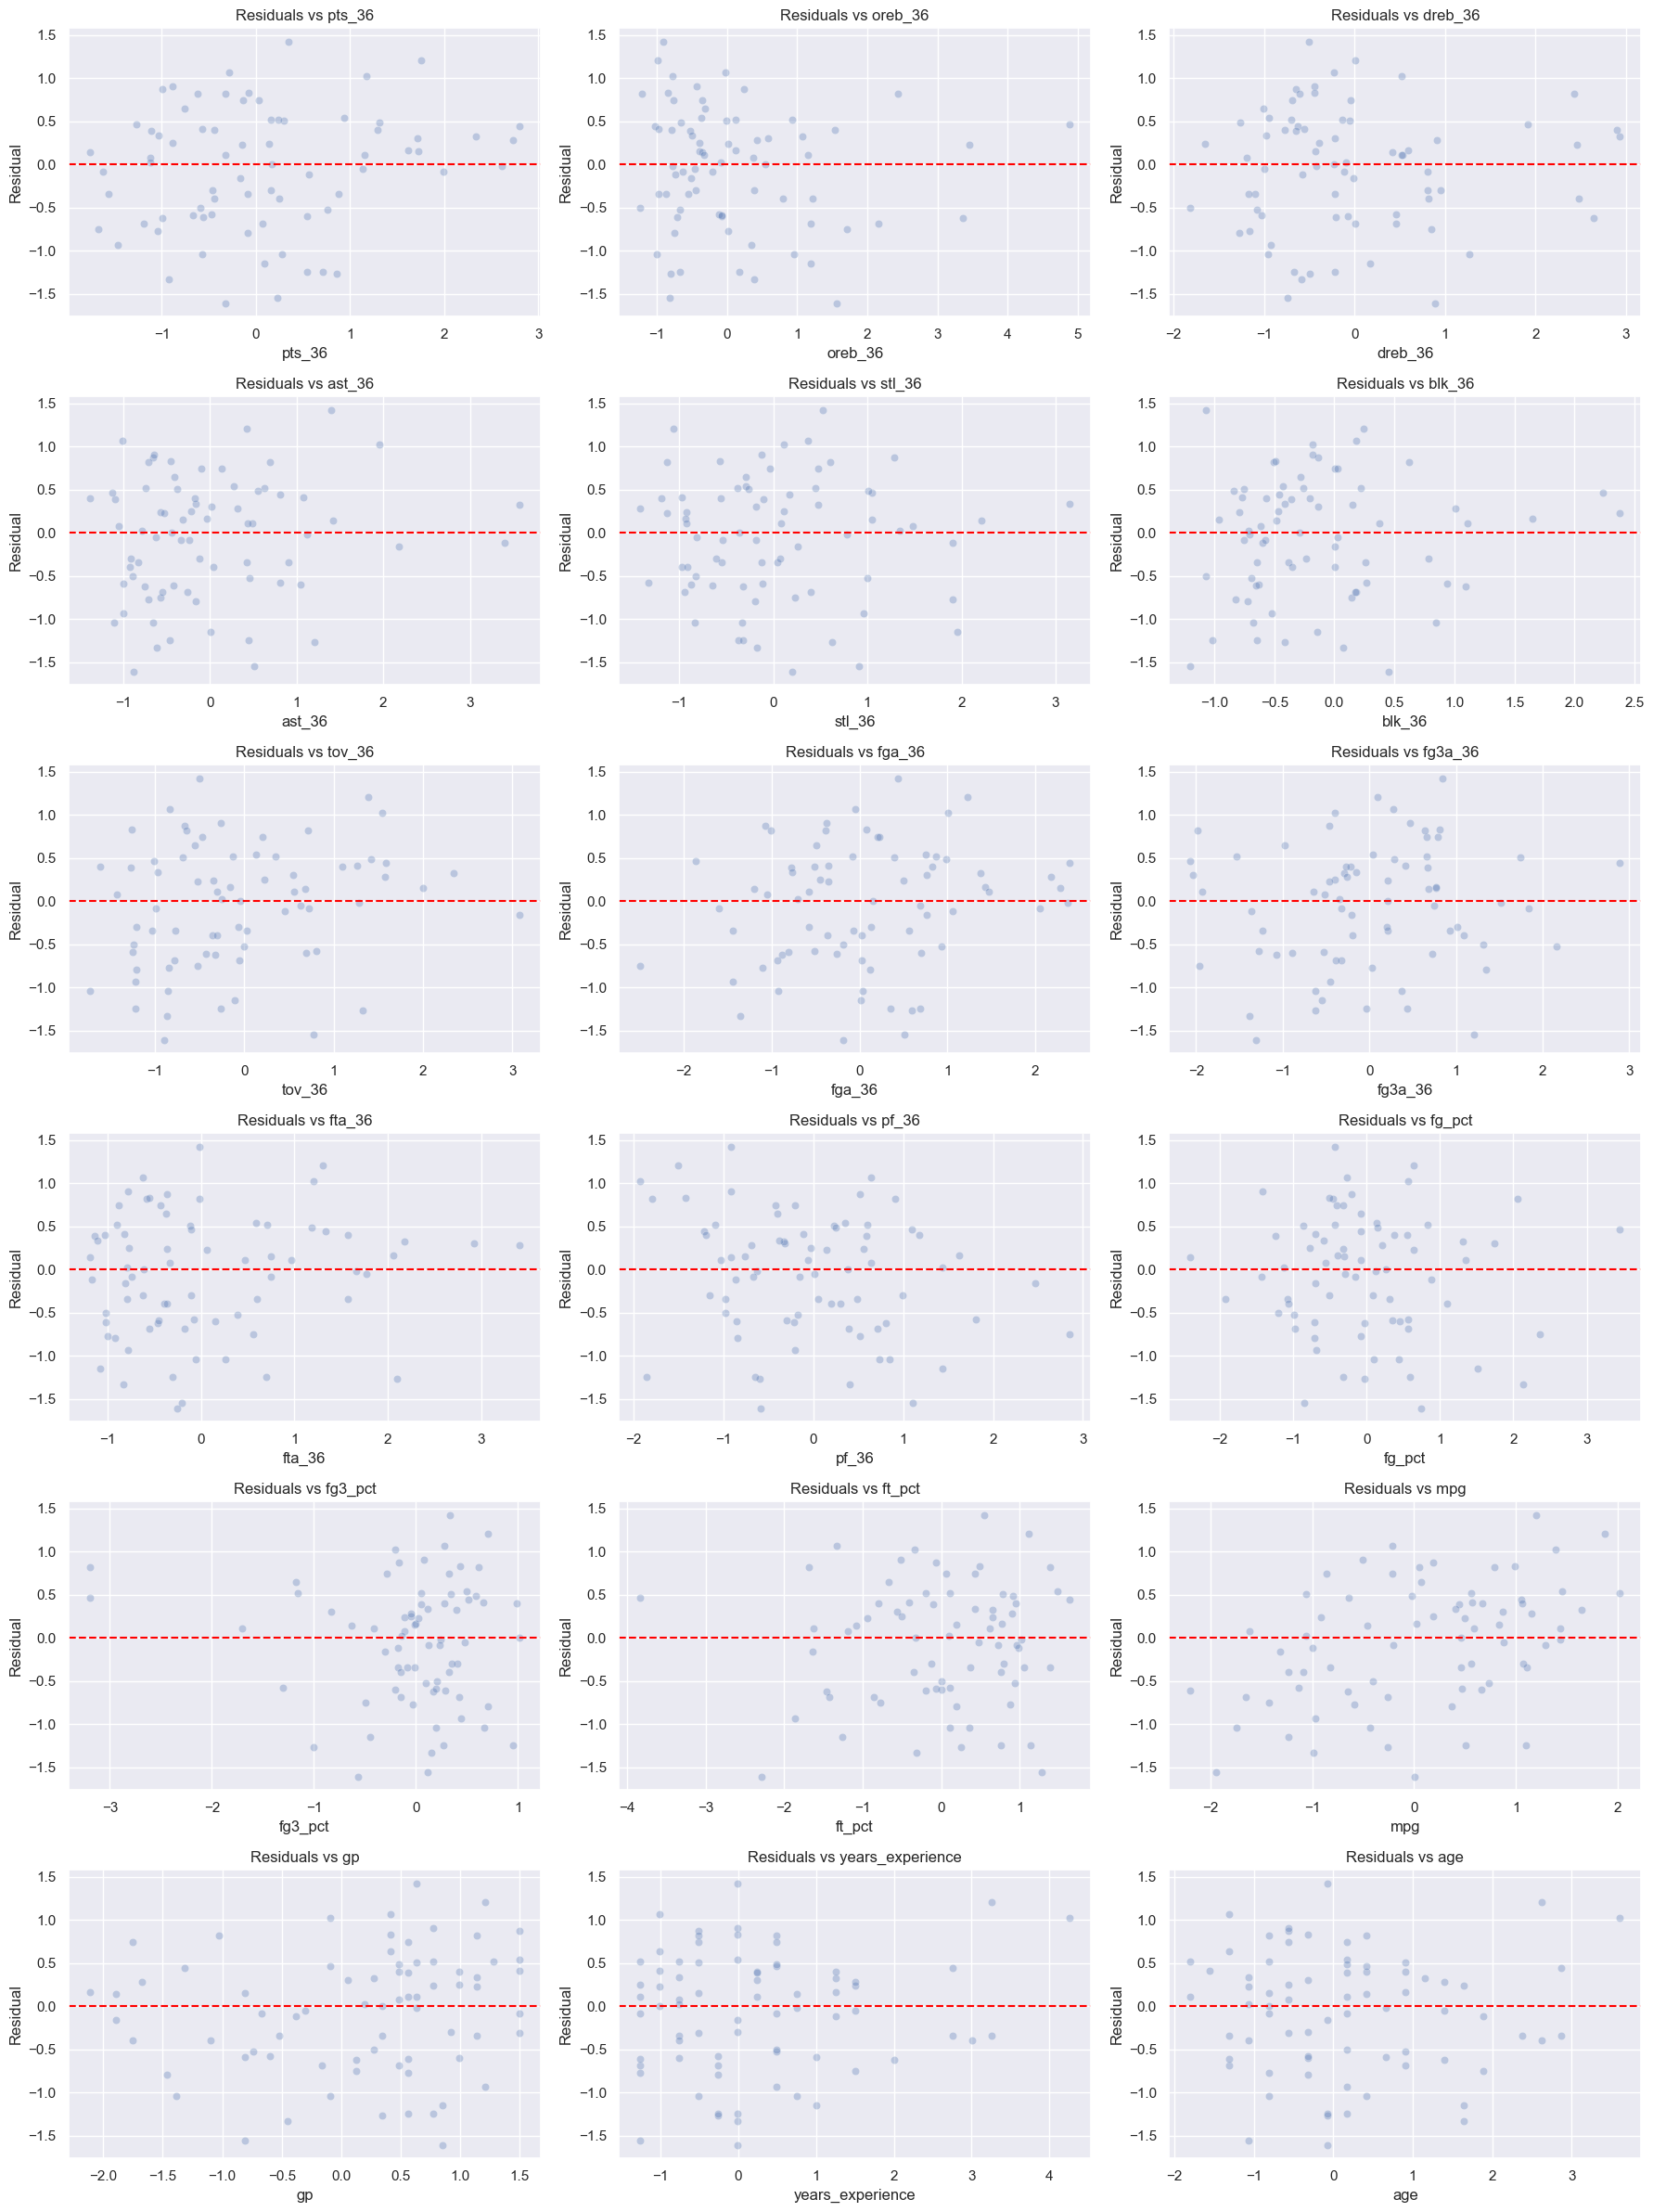

In [20]:
# Initialize results_df and calculate residuals
results_df = X_test.copy()
results_df['Residual'] = y_test - y_pred_xgb

# 1. Get all feature names
features = X_test.columns.tolist()
num_features = len(features)

# 2. Calculate grid dimensions (e.g., 3 columns wide)
cols = 3
rows = math.ceil(num_features / cols)

# 3. Create the figure
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 4))
axes = axes.flatten()  # Flatten to 1D array for easy looping

for i, col in enumerate(features):
    sns.scatterplot(data=results_df, x=col, y='Residual', alpha=0.3, ax=axes[i])
    axes[i].axhline(0, color='red', linestyle='--')
    axes[i].set_title(f'Residuals vs {col}')

# 4. Remove any empty subplots if features don't fill the grid perfectly
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Feature Importance

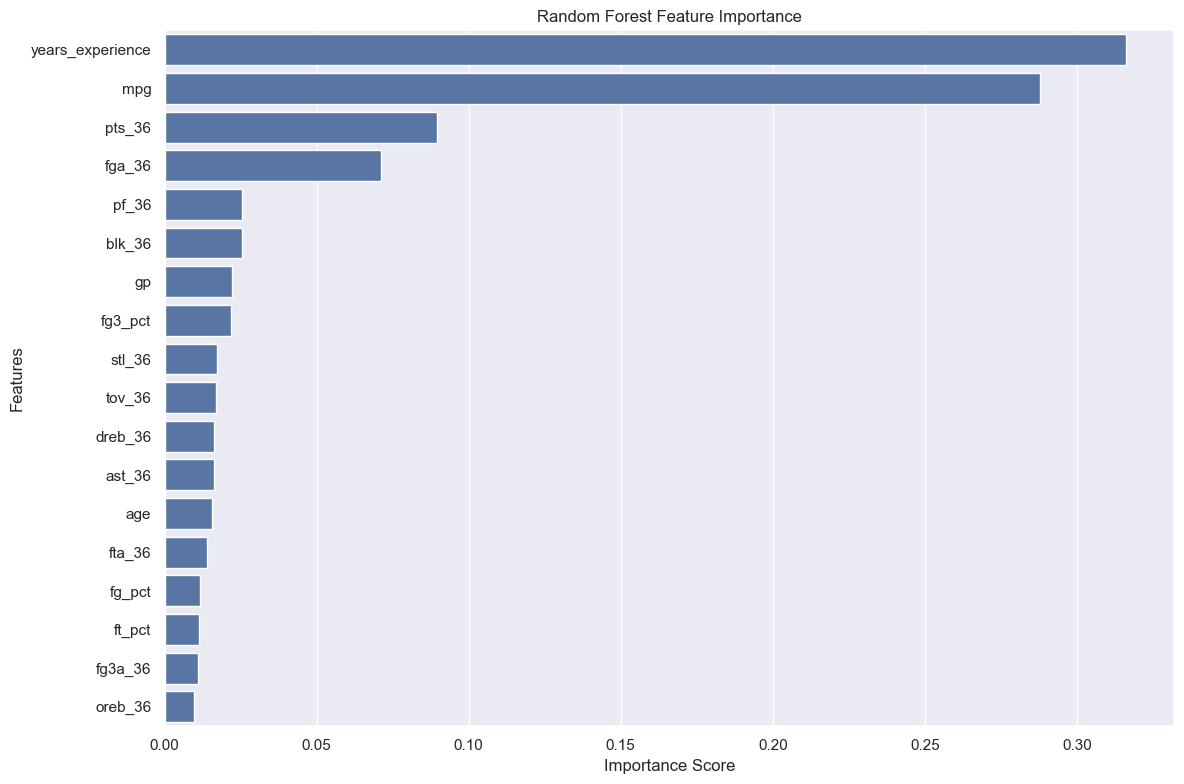

In [21]:
# Calculate and sort feature importances using the best random forest model
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns)
sorted_importances = feature_importances.sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Overpaid vs. Underpaid
### Compare each player's actual salary to the salary the model predicts from their production
### Positive gap = overpaid
### Negative gap = underpaid
### Use cross_val_predict to ensure every player is scored by a model that never trained on them

In [23]:
# ----- Build the value table: predicted "fair" salary vs. actual salary -----
from sklearn.base import clone
from sklearn.model_selection import cross_val_predict, KFold

# Only players with a real salary can be scored (same rows the model was trained on)
value_df = df.dropna(subset=["log_salary"]).copy()
Xv = value_df[model_features]
yv = value_df["log_salary"]

# Out-of-fold predictions: each player scored by a model that did NOT train on them.
# clone(best_rf) reuses the tuned hyperparameters but starts unfitted.
# (RF is scale-invariant, so no scaler needed. To use XGBoost instead, swap in clone(best_xgb).)
cv = KFold(5, shuffle=True, random_state=RNG)
value_df["pred_log_salary"] = cross_val_predict(clone(best_rf), Xv, yv, cv=cv)

# Back to dollars (log_salary is the natural log of salary)
value_df["pred_salary"]   = np.exp(value_df["pred_log_salary"])
value_df["actual_salary"] = value_df["salary"]

# Gap: positive = overpaid, negative = underpaid
value_df["salary_gap"]   = value_df["actual_salary"] - value_df["pred_salary"]
value_df["value_ratio"]  = value_df["actual_salary"] / value_df["pred_salary"]
value_df["log_residual"] = yv.values - value_df["pred_log_salary"]   # model-space residual
value_df["status"]       = np.where(value_df["salary_gap"] > 0, "Overpaid", "Underpaid")

value_df[["player", "team", "cluster", "actual_salary", "pred_salary",
          "salary_gap", "value_ratio", "status"]].head()

,player,team,cluster,actual_salary,pred_salary,salary_gap,value_ratio,status
0,Luka Dončić,LAL,3,45999660.0,3.528737e+07,1.071229e+07,1.303573,Overpaid
1,Shai Gilgeous-Alexander,OKC,3,38333050.0,4.335758e+07,-5.024534e+06,0.884114,Underpaid
2,Jaylen Brown,BOS,3,53142264.0,4.119775e+07,1.194452e+07,1.289931,Overpaid
3,Kevin Durant,HOU,3,54708609.0,2.717864e+07,2.752997e+07,2.012927,Overpaid
4,Tyrese Maxey,PHI,4,37958760.0,3.412650e+07,3.832263e+06,1.112296,Overpaid


In [24]:
# ----- Most overpaid and most underpaid players -----
cols = ["player", "team", "cluster", "actual_salary", "pred_salary", "salary_gap", "value_ratio"]

print("=== 15 MOST OVERPAID (actual >> predicted) ===")
overpaid = value_df.sort_values("salary_gap", ascending=False).head(15)
display(overpaid[cols].round(2))

print("=== 15 MOST UNDERPAID (actual << predicted) ===")
underpaid = value_df.sort_values("salary_gap").head(15)
display(underpaid[cols].round(2))

=== 15 MOST OVERPAID (actual >> predicted) ===


,player,team,cluster,actual_salary,pred_salary,salary_gap,value_ratio
145,Jimmy Butler III,GSW,3,54126450.0,23259702.01,30866747.99,2.33
3,Kevin Durant,HOU,3,54708609.0,27178639.03,27529969.97,2.01
83,Giannis Antetokounmpo,MIL,3,54126450.0,26680684.40,27445765.60,2.03
174,Paul George,PHI,4,51666090.0,24685928.10,26980161.90,2.09
321,Domantas Sabonis,SAC,2,42336000.0,17553088.11,24782911.89,2.41
176,Khris Middleton,DAL,4,33296296.0,8615878.09,24680417.91,3.86
57,Stephen Curry,GSW,4,59606817.0,35944251.30,23662565.70,1.66
132,Jalen Suggs,ORL,4,35000000.0,11600877.10,23399122.90,3.02
56,Immanuel Quickley,TOR,4,32500000.0,9221988.15,23278011.85,3.52
64,OG Anunoby,NYK,0,39568966.0,16913448.51,22655517.49,2.34


=== 15 MOST UNDERPAID (actual << predicted) ===


,player,team,cluster,actual_salary,pred_salary,salary_gap,value_ratio
20,Deni Avdija,POR,3,14375000.0,37104376.16,-22729376.16,0.39
84,Russell Westbrook,SAC,4,2296274.0,23231048.91,-20934774.91,0.10
50,Austin Reaves,LAL,4,13937574.0,33706521.82,-19768947.82,0.41
42,Saddiq Bey,NOP,1,6118644.0,24487545.70,-18368901.70,0.25
16,Nickeil Alexander-Walker,ATL,4,15161800.0,32046964.31,-16885164.31,0.47
166,Kevin Porter Jr.,MIL,4,5134000.0,21933929.63,-16799929.63,0.23
77,Ayo Dosunmu,MIN,4,7518518.0,22190118.19,-14671600.19,0.34
188,De'Anthony Melton,GSW,4,3080921.0,17021788.49,-13940867.49,0.18
155,Kelly Oubre Jr.,PHI,0,8382150.0,21083389.46,-12701239.46,0.40
119,Grayson Allen,PHX,4,16875000.0,28820305.73,-11945305.73,0.59


In [25]:
# ----- Cluster-level pay efficiency -----
# Names from the archetype labels defined in the clustering section
cluster_names = {
    0: "Versatile Forwards & Dynamic Bigs",
    1: "Complementary Wings & Shooting Guards",
    2: "Traditional Centers & Paint Anchors",
    3: "Elite Superstar Frontcourt",
    4: "Elite Scoring Guards & Playmakers",
}
value_df["archetype"] = value_df["cluster"].map(cluster_names)

cluster_value = (value_df.groupby(["cluster", "archetype"])
    .agg(n_players    =("player", "size"),
         avg_actual   =("actual_salary", "mean"),
         avg_predicted=("pred_salary", "mean"),
         avg_gap      =("salary_gap", "mean"),
         median_gap   =("salary_gap", "median"),
         pct_overpaid =("status", lambda s: (s == "Overpaid").mean() * 100))
    .round(0)
    .sort_values("avg_gap", ascending=False))

print("Cluster-level pay efficiency (avg_gap > 0 => cluster tends to be overpaid):")
display(cluster_value)

print("\nTop 2 OVERPAID per cluster:")
display(value_df.sort_values("salary_gap", ascending=False)
        .groupby("cluster").head(2)[cols].sort_values("cluster"))

print("\nTop 2 UNDERPAID per cluster:")
display(value_df.sort_values("salary_gap")
        .groupby("cluster").head(2)[cols].sort_values("cluster"))

Cluster-level pay efficiency (avg_gap > 0 => cluster tends to be overpaid):


,,n_players,avg_actual,avg_predicted,avg_gap,median_gap,pct_overpaid
cluster,archetype,,,,,,
3,Elite Superstar Frontcourt,40,36145266.0,27774459.0,8370807.0,6607588.0,85.0
2,Traditional Centers & Paint Anchors,36,11755882.0,8386649.0,3369233.0,2076619.0,67.0
4,Elite Scoring Guards & Playmakers,86,17680684.0,15071632.0,2609052.0,1188678.0,59.0
0,Versatile Forwards & Dynamic Bigs,95,7849384.0,6792592.0,1056792.0,-39180.0,48.0
1,Complementary Wings & Shooting Guards,106,7572676.0,6594655.0,978021.0,201318.0,51.0



Top 2 OVERPAID per cluster:


,player,team,cluster,actual_salary,pred_salary,salary_gap,value_ratio
64,OG Anunoby,NYK,0,39568966.0,1.691345e+07,2.265552e+07,2.339497
202,Draymond Green,GSW,0,25892857.0,1.257998e+07,1.331288e+07,2.058259
94,Devin Vassell,SAS,1,27000000.0,1.220879e+07,1.479121e+07,2.211521
141,Harrison Barnes,SAS,1,19000000.0,6.914765e+06,1.208523e+07,2.747743
321,Domantas Sabonis,SAC,2,42336000.0,1.755309e+07,2.478291e+07,2.411883
121,Rudy Gobert,MIN,2,35000000.0,1.355618e+07,2.144382e+07,2.581847
145,Jimmy Butler III,GSW,3,54126450.0,2.325970e+07,3.086675e+07,2.327048
3,Kevin Durant,HOU,3,54708609.0,2.717864e+07,2.752997e+07,2.012927
174,Paul George,PHI,4,51666090.0,2.468593e+07,2.698016e+07,2.092937
176,Khris Middleton,DAL,4,33296296.0,8.615878e+06,2.468042e+07,3.864527



Top 2 UNDERPAID per cluster:


,player,team,cluster,actual_salary,pred_salary,salary_gap,value_ratio
155,Kelly Oubre Jr.,PHI,0,8382150.0,2.108339e+07,-1.270124e+07,0.397571
63,Onyeka Okongwu,ATL,0,15000000.0,2.400098e+07,-9.000984e+06,0.624974
42,Saddiq Bey,NOP,1,6118644.0,2.448755e+07,-1.836890e+07,0.249868
172,Bruce Brown,DEN,1,2296274.0,1.153076e+07,-9.234488e+06,0.199143
362,Drew Eubanks,SAC,2,2296274.0,7.651474e+06,-5.355200e+06,0.300109
272,Andre Drummond,PHI,2,5000000.0,9.584201e+06,-4.584201e+06,0.521692
20,Deni Avdija,POR,3,14375000.0,3.710438e+07,-2.272938e+07,0.387421
12,Julius Randle,MIN,3,30864198.0,4.173853e+07,-1.087434e+07,0.739465
84,Russell Westbrook,SAC,4,2296274.0,2.323105e+07,-2.093477e+07,0.098845
50,Austin Reaves,LAL,4,13937574.0,3.370652e+07,-1.976895e+07,0.413498


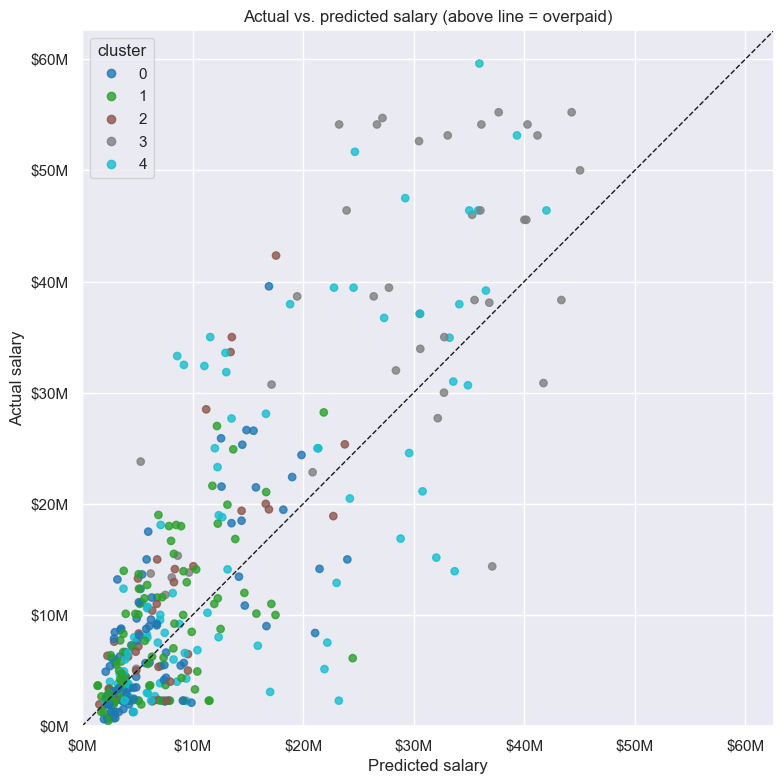

In [27]:
import matplotlib.ticker as mticker
millions = mticker.FuncFormatter(lambda x, _: f"${x/1e6:.0f}M")

# (a) Predicted vs. actual — points above the line are overpaid, below are underpaid
fig, ax = plt.subplots(figsize=(8, 8))
sc = ax.scatter(value_df["pred_salary"], value_df["actual_salary"],
                c=value_df["cluster"], cmap="tab10", s=28, alpha=0.8)
lims = [0, value_df[["pred_salary", "actual_salary"]].max().max() * 1.05]
ax.plot(lims, lims, "k--", lw=1, label="fair pay (actual = predicted)")
ax.set(xlim=lims, ylim=lims, xlabel="Predicted salary", ylabel="Actual salary",
       title="Actual vs. predicted salary (above line = overpaid)")
ax.xaxis.set_major_formatter(millions); ax.yaxis.set_major_formatter(millions)
ax.legend(*sc.legend_elements(), title="cluster", loc="upper left")
plt.tight_layout(); plt.show()

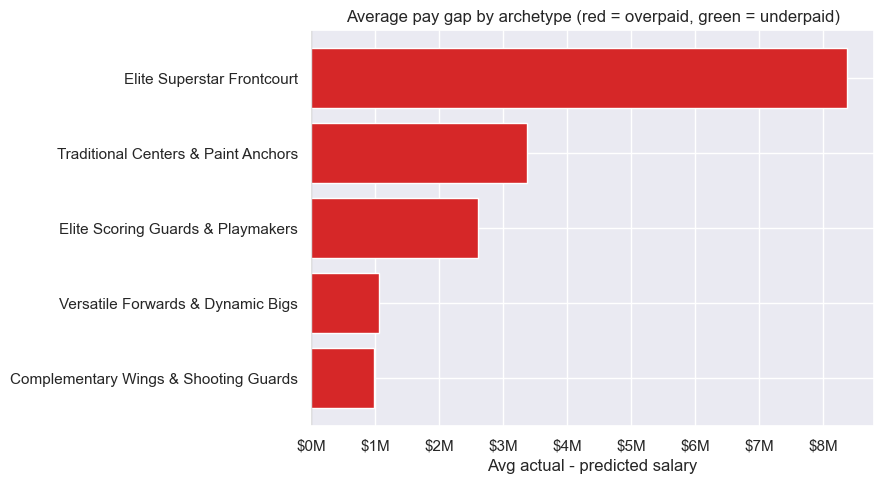

In [28]:
# (b) Average pay gap by archetype
fig, ax = plt.subplots(figsize=(9, 5))
order = cluster_value.reset_index().sort_values("avg_gap")
colors = ["#d62728" if g > 0 else "#2ca02c" for g in order["avg_gap"]]
ax.barh(order["archetype"], order["avg_gap"], color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set(title="Average pay gap by archetype (red = overpaid, green = underpaid)",
       xlabel="Avg actual - predicted salary")
ax.xaxis.set_major_formatter(millions)
plt.tight_layout(); plt.show()

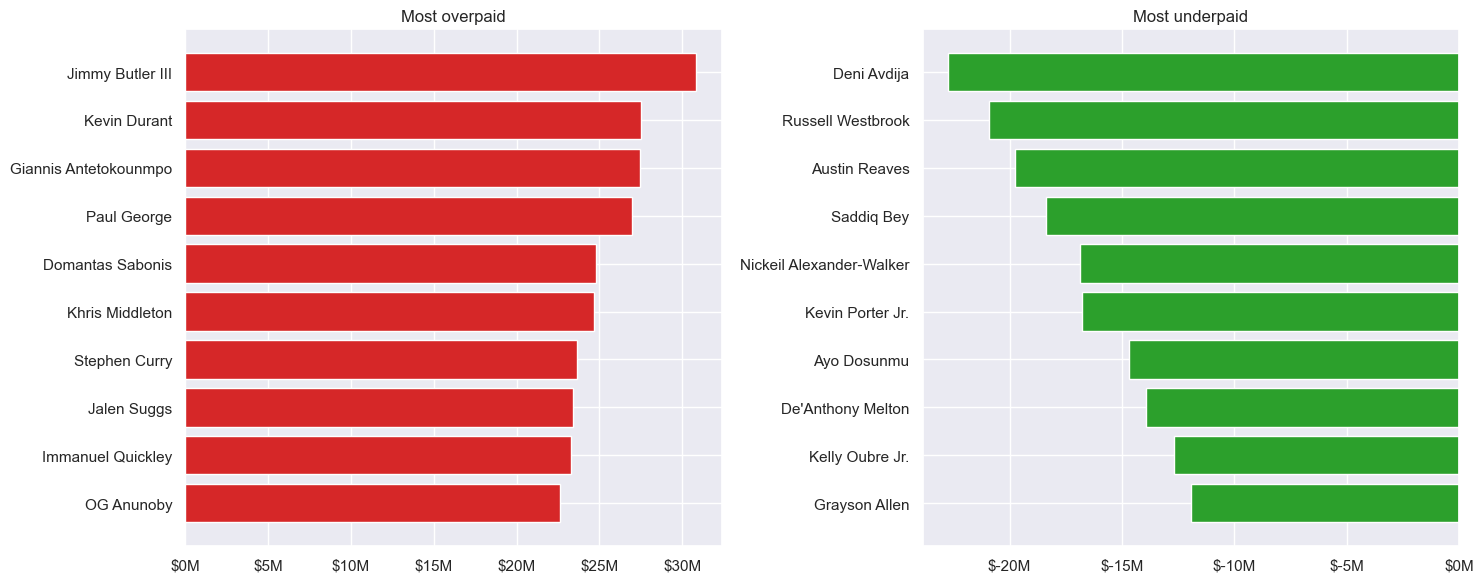

In [29]:
# (c) Top 10 overpaid vs. top 10 underpaid players
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
top_over  = value_df.sort_values("salary_gap", ascending=False).head(10)
top_under = value_df.sort_values("salary_gap").head(10)
axes[0].barh(top_over["player"], top_over["salary_gap"], color="#d62728")
axes[0].set_title("Most overpaid"); axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(millions)
axes[1].barh(top_under["player"], top_under["salary_gap"], color="#2ca02c")
axes[1].set_title("Most underpaid"); axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(millions)
plt.tight_layout(); plt.show()

# Summary

<br> - Loaded the preprocessed dataset and the pickled cluster matrix / train-test split from Step 3
<br> - Chose k=5 for K-Means from the elbow and silhouette curves, then profiled the 5 player archetypes
<br> - Compared Linear Regression vs. Random Forest by 5-fold CV R-squared - Random Forest generalized better
<br> - Tuned Random Forest and XGBoost with GridSearchCV (MAE objective) and scored them on the held-out test set
<br> - Plotted residuals against every feature
<br> - Ranked the drivers of pay with feature importance
<br> - Used out-of-fold predictions to flag the most overpaid and underpaid players and to measure pay efficiency by archetype

# Analysis

<br> - The first place feature is Years of Experience. This aligns with the Collective Barganing Agreement (CBA): 25% if yos <= 6 else 30% if yos <= 9 else 35%
<br> - The second place feature is minutes per game (MPG). This reflects the role and trust given to a place. Since production stats were normalized to 36 min, they carry no volume information. MPG is picking this signal up instead.
<br> - Overpaid players are almost all max-contract stars: the largest positive gaps belong to Jimmy Butler, Kevin Durant, Giannis Antetokounmpo, Paul George, and Stephen Curry (clusters 3 and 4). Their production is elite, but the CBA maximum salary sits well above what any production-based model can predict, so the league's top earners naturally read as overpaid.
<br> - Underpaid players are productive names on cheap contracts: Austin Reaves, Deni Avdija, Nickeil Alexander-Walker, and several rookie-scale or minimum guards (cluster 4) produce like players earning two to three times more
<br> - Cluster 3 (Elite Superstar Frontcourt) is the most overpaid group (avg +$8.4M, 85% of players above their prediction), followed by traditional centers (cluster 2) and scoring guards (cluster 4). 
<br> - Versatile Forwards (cluster 0) and Complementary Wings (cluster 1) are the most efficiently paid, with median gaps near zero.
<br> - Use the ranking, not the raw dollars: because the target is log-salary, converting predictions back to dollars adds a mild upward bias to every actual-minus-predicted gap (which is why every cluster averages slightly positive). The player ordering and the value_ratio are the reliable signals for who is over- or underpaid.